# Precision, at a candidate list short enough to be one

**The question.** `tm_threshold_axis_sweep_largest_cc_high_z.ipynb` (below: *high_z*) asked how
high the `z` cutoff can go before a mitosis is lost, and answered `z_max` -- 1.3 to 15.5 over the
70 (ROI, seed) cells `recall_workload_ledger.py` later measured. Every cutoff it considered was
at or below that ceiling, so **recall was pinned at 1.0 by construction and precision was never
reported at all**. This notebook goes the other way: it pushes `z` up until fewer than **50**
candidates reach NMS *at all*, and reports what fraction of that list is a real mitotic figure.

Everything else is held: `hematoxylin_od`, `TM_CCOEFF` (D1), largest-connected-component
template tightening, `peak_min_distance = 7`, NMS at 5.0 um decoupled from the 7.5 um match
radius, border padding so the whole ROI is reachable, `self_hit_radius = 5.0`, and the
`np.random.default_rng([seed_index, image_id])` seed draw with `draw_seed_with_retry` on
`largest_cc_box`. The only new knob is the candidate budget.

**Scope: the 14 ROIs of `images/extra_valid/`, 5 seeds, 70 cells.** high_z ran 7 ROIs from
`images/`; those 7 are a strict subset of these 14 (checked below), so this is a superset, not a
substitution. Two things follow. D4's "worst ROI, worst click, per domain" rule gets its ROI half
exercised for the first time in this family, and -- more usefully here -- every cell reproduces
`results/tm_recall_workload_cells.csv` bit-for-bit on `seed_ann_id`, `base_size`, `map_median`,
`mad_scale` and the `z = 1.0` list length, which is a cross-run gate this notebook did not have to
build.

## What "fewer than 50 candidates" means, precisely

The pipeline is `extract_peaks` -> `nms_by_distance` -> self-hit filter. The budget is applied at
the **first** of those: the cutoff is set so that `extract_peaks` returns fewer than 50 peaks, i.e.
fewer than 50 candidates are fed into NMS *to begin with*. NMS and the self-hit filter can only
shorten that further, so the list the reader is handed is also under 50. All three counts are
reported separately (`n_pre_nms`, `n_post_nms`, `n_detections`) rather than collapsed into one.

The cut is exact and needs no search. `extract_peaks` computes its local-maximum mask as
`(fused >= dilate(fused)) & valid & (fused >= score_threshold)`; the dilation does not depend on
the threshold, so raising it is a pure filter and the peak list at any higher cutoff is an exact
**prefix** of the list at a lower one -- guaranteed elementwise by `np.lexsort((ys, xs, -scores))`,
a global key that restricts to a subset unchanged. So the budget-`B` cutoff is just "one notch
above the `B`-th peak", applied in raw score units so no `med + z*mad` round trip can move it.
Verified against a direct re-extraction below, not assumed.

## Read this before reading any number below

* **`recall` here is genuine recall, and so was the old one -- but it was recall of the wrong
  thing.** I re-derived the old column rather than assuming: `compare.evaluate_arms` computes
  `full_list_recall = (# detections bucketed human_correct_label) / n_gt_mitotic`, and
  `evaluate.greedy_match` claims each annotation at most once, so the numerator *is* the number
  of mitotic annotations matched. That is TP / (TP + FN). The arithmetic was never wrong. What
  was wrong is that it is the recall of a **candidate pool** -- 12,231 to 38,876 points at
  `z = 1.0` -- reported on its own, at a `coverage_frac` of 0.9+, where `evaluate.py`'s own
  docstring says the metric is answering *"is this annotation within 7.5 um of some detection?"*
  by geometry. A number that can be driven to 1.0 by emitting everything is not a result until it
  is paired with the thing emitting everything destroys. That pairing is this notebook. The full
  argument, with the measured coverage on both sides, is in the last section.
* **The NMS radius is back at the 7.5 um default, and that is a change from high_z.** high_z and
  `recall_workload_ledger.py` both ran 5.0 um, inherited from `tm_threshold_axis_sweep_v2.ipynb`.
  `FSConfig.nms_radius = None` means "this image's evaluation match radius" and
  `invariants.check_nms_radius` requires exactly that, so 5.0 was an override of Invariant 4, and
  F5 -- the ablation built to attribute v2's gain -- concluded on 2026-09-08 that the gain came
  from the padding and recommended putting the radius back. It matters more here than it did there:
  a suppression radius **below** the match radius lets two survivors sit on one annotation, and
  `greedy_match` then credits one and buckets the other `non_human_findings` -- a false positive
  that is a real mitotic figure by eye. On a 50-item list a handful of those moves precision by
  several points. F5 measured that duplicate rate at 0.0027 / 0.0043 / 0.0047 for 7.5 / 5.9 / 5.0 um.
* **Equal radii shrink that defect but do not remove it**, so it is still counted. Two detections
  each within `r` of the same annotation can be more than `r` apart -- at 0.9r from the annotation
  they need only 68 degrees of separation -- so NMS at the match radius does not forbid the
  configuration, it just makes it rare. `fp_dup_on_mitotic` counts it and precision is reported
  **both** ways, strict and de-duplicated. Neither is "the" answer; the gap between them is a
  property of the radius pair, and at the default it should be close to zero.
* **Precision has to be read against its own null.** Mitotic density varies 14x across these ROIs
  (17 to 238 annotations), and precision rises with density for free. The null is stated exactly:
  a uniformly-random point in the ROI lands within `match_radius` of a mitotic annotation with
  probability `coverage_fraction(mitotic_gt_xy)`, which is `evaluate.py`'s own function applied to
  the annotations instead of the detections. Every precision number is reported next to that
  ROI's own null and as a lift over it.
* **The budget is a count, not a label-fitted threshold.** Unlike high_z's `z_max`, "take the top
  50 peaks" needs no ground truth, so the resulting `z` is deployable in a way `z_max` is not. It
  is also *far* above anything previously considered: the cutoffs this produces sit at
  `z = 6` to `z = 30`, against high_z's grid ceiling of 3.0.
* **`chromatin_od` is not run.** Re-ranking a fixed candidate set changes neither its full-list
  precision nor its recall, which are the only two quantities this notebook reports, so the second
  axis has nothing to move here. It also stays non-decision-grade under D5. One line, then dropped.

In [1]:
import time
NB_T0 = time.time()

import gc
import os
import pathlib

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from skimage.measure import label, regionprops
from sklearn.neighbors import KDTree

from midog_utils import channels as ch
from midog_utils import compare as cp
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import experiment as ex
from midog_utils import find_and_suppress as fs
from midog_utils import invariants as inv
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
print('imports ok')

imports ok


## Configuration

Copied from `recall_workload_ledger.py` -- which copied it from high_z -- rather than re-derived,
so that a difference in any shared quantity is a bug and not config drift. The two additions are
`BUDGETS_PRE` (the candidate budgets, applied **before** NMS) and `HEADLINE_BUDGET = 50`, which is
the operating point the question asks about.

`EXTRACT_FLOOR_Z = CURRENT_Z = 1.0` replaces high_z's `DEEP_FLOOR_Z = -1.5` as the floor peaks are
extracted at. This is not a change of operating point -- it is the *deepest list this notebook ever
scores*, and it is legitimate for two independent reasons. By the prefix argument above, every
budget considered here is a prefix of the `z = 1.0` peak list, so nothing that could be reported is
excluded; and `recall_workload_ledger.py`'s self-test 6 measured directly that **every** mitosis in
all 70 cells ranks inside the `z = 1.0` list, so the deeper floor could not add a true positive
either. It cuts NMS from ~500k points to ~20k, which is what makes this a 15-minute notebook.

In [2]:
IMAGES_DIR = 'images/extra_valid'          # 14 ROIs, 2 per domain -- D5's set
SEEDS = tuple(range(5))

CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF                     # D1
PEAK_MIN_DISTANCE = 7
SELF_HIT_RADIUS = 5.0
CURRENT_Z = 1.0                            # the operating point everything is measured against
EXTRACT_FLOOR_Z = CURRENT_Z                # see the note above: the deepest list ever scored here
MAX_PEAKS = 2_000_000

MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM       # 7.5
# THE REPO DEFAULT, and a deliberate departure from high_z / recall_workload_ledger.py, which
# both ran 5.0. `FSConfig.nms_radius = None` means "this image's evaluation match radius";
# `invariants.check_nms_radius` requires exactly that and is the only reason the 5.0 runs had to
# override it. F5's verdict (`f5_nms_radius_ablation.ipynb` section 11, corrected 2026-09-08) is
# explicit: *"Padding ON, NMS radius back at the 7.5 um default -- which also restores
# invariants.check_nms_radius instead of overriding it."* Shrinking it was a real cost under
# chromatin ranking, a near-no-op under score ranking, and a benefit under neither; v2's
# improvement came from the padding. It matters here more than it did there, because a
# suppression radius below the match radius lets two survivors sit on one annotation, and this
# notebook's headline is precision over a 50-item list where a few such rows move it several
# points. Invariant 4 is asserted per cell below rather than left to the config.
NMS_RADIUS_UM = MATCH_RADIUS_UM
LEGACY_NMS_RADIUS_UM = 5.0                 # high_z / ledger / v2's value, scored as a DIAGNOSTIC
                                           # arm at the headline budget only -- never used to rank

CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2               # 36
OTSU_WINDOW = tm.BASE_SIZE                 # 51
LARGEST_CC_KW = dict(min_area=50, max_area_frac=0.85, min_solidity=0.5)

# NEW. Budgets are counts of peaks handed to NMS, not z values: z is per-map and a fixed z
# delivers wildly different list lengths across ROIs, which is the whole reason high_z's
# `z_max` was not a threshold. A count is comparable across ROIs by construction.
BUDGETS_PRE = (10, 25, 50, 100, 250, 500, 1000, 2500, 5000)
HEADLINE_BUDGET = 50                       # "fewer than 50 candidates fed into NMS"
assert HEADLINE_BUDGET in BUDGETS_PRE

OUT_CELLS = 'results/tm_precision_under50_cells.csv'
OUT_BUDGETS = 'results/tm_precision_under50_budgets.csv'

# Categorical slots 1 and 2 of the validated default palette (blue, orange). Two hues only,
# and identity is carried by a direct label as well as by colour.
COL_RECALL, COL_PRECISION = '#2a78d6', '#eb6834'
INK, INK_MUTED, GRID = '#0b0b0b', '#52514e', '#dcdcd8'
print(f'config ok | {len(BUDGETS_PRE)} budgets, headline = fewer than {HEADLINE_BUDGET} pre-NMS')

config ok | 9 budgets, headline = fewer than 50 pre-NMS


## `largest_cc_box` and `draw_seed_with_retry` -- copied verbatim

Unchanged from high_z and `recall_workload_ledger.py`, synthetic retry test included, so this
notebook's seed draw is provably the same one and the reproduction gate below is meaningful. Still
local rather than in `midog_utils/seed_selection.py`, for the original reason: this rule was probed
and explicitly *not* adopted as production logic
(`Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`, Experiment 5).

In [3]:
def _odd_local(n: int, minimum: int = 5) -> int:
    n = int(round(n))
    if n % 2 == 0:
        n += 1
    return max(minimum, n)


def largest_cc_box(patch, min_area=50, max_area_frac=0.85, min_solidity=0.5):
    '''Otsu-threshold `patch` and return the bbox of its LARGEST connected component by area,
    regardless of whether it contains the click. (y0, y1, x0, x1), patch-local, half-open,
    or None.'''
    if patch.ndim != 2:
        raise ValueError(f'largest_cc_box needs a single-channel patch, got {patch.shape}')
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    regions = regionprops(label(binary, connectivity=2))
    if not regions:
        return None
    largest = max(regions, key=lambda r: r.area)
    if largest.area < min_area:
        return None
    if largest.area > max_area_frac * patch.size:
        return None
    if largest.solidity < min_solidity:
        return None
    y0, x0, y1, x1 = largest.bbox
    return int(y0), int(y1), int(x0), int(x1)


def draw_seed_with_retry(pool: pd.DataFrame, rng, check_fn):
    '''Draw a row via `rng.integers`; on failure drop it and redraw, consuming the same rng
    stream. Returns (row, result, n_retries). Raises if the pool empties.'''
    working = pool.copy()
    retries = 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no candidate passed check_fn after all retries')


class _StubRNG:
    def integers(self, n):
        return 0


_fake = pd.DataFrame({'val': [10, 20, 30]}, index=[100, 101, 102])
_row, _res, _ret = draw_seed_with_retry(_fake, _StubRNG(),
                                        lambda r: None if r['val'] == 10 else r['val'])
assert (_row['val'], _res, _ret) == (20, 20, 1), 'retry path regressed'
try:
    draw_seed_with_retry(pd.DataFrame({'val': [1, 2]}), _StubRNG(), lambda r: None)
    raise AssertionError('expected ValueError on pool exhaustion')
except ValueError:
    pass
print('largest_cc_box / draw_seed_with_retry defined; both synthetic retry paths pass')

largest_cc_box / draw_seed_with_retry defined; both synthetic retry paths pass


## The 14 ROIs, and the check that they contain high_z's 7

In [4]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
META = images.set_index('file_name')[['image_id', 'tumor_type']]
FILES = sorted(f for f in os.listdir(IMAGES_DIR) if f.endswith('.tiff'))

_rows = []
for fn in FILES:
    gt = ds.image_annotations(annotations, fn)
    mpp = ds.roi_mpp(f'{IMAGES_DIR}/{fn}')
    _rows.append({'tumor_type': META.loc[fn, 'tumor_type'], 'file_name': fn,
                  'n_mitotic': int((gt['category_id'] == ds.MITOTIC).sum()),
                  'n_lookalike': int((gt['category_id'] == ds.LOOKALIKE).sum()),
                  'mpp': round(mpp, 4),
                  'match_radius_px': round(ev.radius_px(mpp, MATCH_RADIUS_UM), 2),
                  'nms_radius_px': round(ev.radius_px(mpp, NMS_RADIUS_UM), 2)})
roi_table = pd.DataFrame(_rows).sort_values(['tumor_type', 'file_name']).reset_index(drop=True)

_hz7 = set(ex.select_domain_images(images, annotations, images_dir='images')['file_name'])
assert _hz7 <= set(FILES), f"high_z's ROIs are not a subset of {IMAGES_DIR}: {_hz7 - set(FILES)}"
print(f"{len(FILES)} ROIs x {len(SEEDS)} seeds = {len(FILES) * len(SEEDS)} cells.")
print(f"high_z's 7 ROIs ({', '.join(sorted(_hz7))}) are all inside this set, so it is a superset.")
print(f"NMS radius == match radius in every ROI: "
      f"{bool((roi_table['nms_radius_px'] == roi_table['match_radius_px']).all())} "
      f"({roi_table['match_radius_px'].min():.1f}-{roi_table['match_radius_px'].max():.1f} px) "
      f"-- the repo default, which high_z and the ledger overrode to 5.0 um.")
roi_table

14 ROIs x 5 seeds = 70 cells.
high_z's 7 ROIs (094.tiff, 201.tiff, 246.tiff, 301.tiff, 402.tiff, 459.tiff, 548.tiff) are all inside this set, so it is a superset.
NMS radius == match radius in every ROI: True (29.6-33.1 px) -- the repo default, which high_z and the ledger overrode to 5.0 um.


,tumor_type,file_name,n_mitotic,n_lookalike,mpp,match_radius_px,nms_radius_px
0,canine cutaneous mast cell tumor,300.tiff,181,85,0.2533,29.61,29.61
1,canine cutaneous mast cell tumor,301.tiff,218,109,0.2533,29.61,29.61
2,canine lung cancer,201.tiff,18,49,0.2482,30.22,30.22
3,canine lung cancer,233.tiff,18,23,0.2482,30.22,30.22
4,canine lymphosarcoma,245.tiff,90,70,0.2482,30.22,30.22
5,canine lymphosarcoma,246.tiff,116,123,0.2482,30.22,30.22
6,canine soft tissue sarcoma,459.tiff,131,90,0.2482,30.22,30.22
7,canine soft tissue sarcoma,460.tiff,36,40,0.2482,30.22,30.22
8,human breast cancer,013.tiff,18,15,0.2263,33.14,33.14
9,human breast cancer,094.tiff,82,102,0.2298,32.63,32.63


## The metrics, defined once, named for what they are over

Every number below comes out of this one function, so there is exactly one place to check what a
column means. The three counts and the two rates:

| column | definition |
|---|---|
| `n_pre_nms` | candidates `extract_peaks` returns -- **the budgeted quantity** |
| `n_post_nms` | survivors of `nms_by_distance` at 5.0 um |
| `n_detections` | after the self-hit filter -- the list a reader is handed |
| `tp` | detections greedily matched to a category-1 (mitotic) annotation |
| `fp_lookalike` | matched to a category-2 annotation -- a structure a pathologist examined and rejected |
| `fp_unannotated` | matched to nothing |
| `fp_dup_on_mitotic` | of `fp_unannotated`, those within `match_radius` of a mitotic annotation an earlier detection already claimed. Rare at the default NMS radius, not impossible -- see the intro |
| **`recall_mitotic`** | `tp / n_gt_mitotic_eval` = **TP / (TP + FN)**. Mathematical recall over mitotic annotations, seed excluded. |
| **`precision_mitotic`** | `tp / n_detections` = **TP / (TP + FP)**. Strict: a duplicate on a real mitosis counts against it. |
| `precision_mitotic_dedup` | `(tp + fp_dup_on_mitotic) / n_detections` -- the same list scored as if landing on an already-claimed mitosis were not an error |
| `null_hit_frac` | `coverage_fraction(mitotic_gt_xy)`: the probability **one** uniformly random ROI point falls within `match_radius` of a mitotic annotation |
| `null_precision` | the precision a *random list of this length* would get -- `null_hit_frac` corrected for the fact that greedy matching caps true positives at `n_gt_mitotic_eval`, so a long random list scores worse per item than a short one (formula and its one assumption in the cell below) |
| `coverage_frac` | fraction of the ROI within `match_radius` of *some* detection -- `evaluate.py`'s saturation guard, computed on the detections |

Two labelling rules this notebook keeps and its predecessors did not:

1. **No number is labelled with a budget it did not deliver.** `compare.evaluate_arms` emits
   `recall_at_budget` at every value in `cp.BUDGETS` even when the list is shorter than the budget,
   so on a 40-detection arm the column headed `recall@5000` is the full-list recall. It records
   `budget_delivered` alongside, but the *name* still claims a budget that never happened. Here the
   requested budget and the delivered counts are separate columns and every table prints both.
2. **The null is length-aware, because a per-point null is wrong for a long list.** With
   `n_gt_mitotic_eval` annotations and one-to-one greedy matching, no list of length `K` can exceed
   `n_gt / K` precision, and a random list of 16,000 points already covers most of the annotations
   -- so scoring it at the per-point rate over-credits it and can make a real detector look *worse*
   than random. Both quantities are reported: `null_hit_frac` (the per-point rate) and
   `null_precision` (the same thing corrected for length). The first draft of this notebook used
   only the first and concluded the `z = 1.0` pool was 0.6x random, which is an artefact of exactly
   that error.
3. **The null is uniform over the ROI, not over tissue.** D2 removed the tissue mask, so there is
   no tissue-restricted null available and this one is mildly optimistic for the lift -- real
   detections sit on tissue, and so would a fairer null. Stated rather than corrected, since
   correcting it would reintroduce the mask D2 removed.

In [5]:
def score_list(det: pd.DataFrame, gt_eval: pd.DataFrame, match_radius: float,
               mit_tree, n_mit: int, roi_shape=None) -> dict:
    '''Every metric this notebook reports, for ONE ranked detection list.

    `det` must already be in its final ranking -- `evaluate.bucket_detections` matches greedily
    in row order, so bucketing an unsorted frame scores a different ranking than the one named.
    `mit_tree` is a KDTree over the MITOTIC rows of `gt_eval` only, used for the duplicate count.
    `roi_shape` None skips `coverage_frac` (the expensive part) and returns NaN for it.
    '''
    det_out, _ = ev.bucket_detections(det, gt_eval, match_radius)
    b = det_out['bucket'].to_numpy()
    n = len(det_out)
    tp = int((b == ev.HUMAN_CORRECT_LABEL).sum())
    lk = int((b == ev.HUMAN_REJECTED_LABEL).sum())
    un = int((b == ev.NON_HUMAN_FINDINGS).sum())

    # A second detection on an already-claimed mitosis. Not forbidden even at
    # NMS_RADIUS_UM == MATCH_RADIUS_UM (two points 0.9r from one annotation, 68 degrees apart,
    # are more than r from each other), so it is counted rather than argued about.
    if n and mit_tree is not None:
        d, _ = mit_tree.query(det_out[['cx', 'cy']].to_numpy(), k=1)
        dup = int(((d[:, 0] <= match_radius) & (b == ev.NON_HUMAN_FINDINGS)).sum())
    else:
        dup = 0

    prec = tp / n if n else float('nan')
    prec_dd = (tp + dup) / n if n else float('nan')
    rec = tp / n_mit if n_mit else float('nan')
    f1 = (2 * prec * rec / (prec + rec)) if (n and n_mit and (prec + rec) > 0) else float('nan')
    cov = (ev.coverage_fraction(det_out[['cx', 'cy']].to_numpy(), roi_shape, match_radius)
           if roi_shape is not None else float('nan'))
    return {'n_detections': n, 'tp': tp, 'fp_lookalike': lk, 'fp_unannotated': un,
            'fp_dup_on_mitotic': dup, 'n_gt_mitotic_eval': n_mit,
            'n_mitotic_missed': n_mit - tp,
            'recall_mitotic': rec, 'precision_mitotic': prec,
            'precision_mitotic_dedup': prec_dd, 'f1_mitotic': f1, 'coverage_frac': cov}


def null_precision_at(k: int, hit_frac: float, n_gt: int) -> float:
    '''Precision a random list of length `k` would score, in expectation.

    `hit_frac` is the measured probability that ONE uniform ROI point lands within the match
    radius of some mitotic annotation. Modelling each annotation as its own disc of that radius
    and the discs as disjoint gives a per-annotation hit probability `a = hit_frac / n_gt`, so
    `k` independent points cover annotation `i` with probability `1 - (1-a)**k`, and

        E[TP] = n_gt * (1 - (1 - hit_frac / n_gt) ** k)

    because greedy matching claims each annotation at most once. Dividing by `k` gives the
    precision. At small `k` this collapses to `hit_frac`; at large `k` it approaches the hard
    ceiling `n_gt / k` that one-to-one matching imposes on ANY list, which is why a per-point
    null is not usable for the 12k-39k candidate pools this notebook compares against.

    The disjoint-disc assumption is the one approximation. On these ROIs the annotation discs
    occupy 0.1-2% of the area, so the union correction is below 1% of `hit_frac`.
    '''
    if n_gt <= 0 or k <= 0:
        return float('nan')
    a = hit_frac / n_gt
    return float(n_gt * (1.0 - (1.0 - a) ** k) / k)


# `k = 1` must return the measured per-point rate, and a very long list must approach the
# one-to-one ceiling n_gt / k. Both checked rather than asserted in a comment.
assert np.isclose(null_precision_at(1, 0.0015, 17), 0.0015)
assert null_precision_at(10 ** 7, 0.0015, 17) < 17 / 10 ** 7 * 1.0000001
assert null_precision_at(10 ** 7, 0.0015, 17) > 17 / 10 ** 7 * 0.999
assert null_precision_at(48, 0.0015, 17) < 0.0015          # monotone decreasing in k
assert null_precision_at(48, 0.0015, 17) > null_precision_at(480, 0.0015, 17)

# --- self-test. Two detections inside one mitosis's radius, one on a look-alike, one on nothing;
# two mitotic annotations, one of them never found. Every branch of the function is exercised.
_gt = pd.DataFrame({'cx': [100.0, 900.0, 500.0], 'cy': [100.0, 900.0, 500.0],
                    'ann_id': [1, 2, 3], 'category_id': [ds.MITOTIC, ds.MITOTIC, ds.LOOKALIKE],
                    'unanimous': [True, True, True], 'n_votes': [2, 2, 2],
                    'n_mitotic_votes': [2, 2, 0]})
_det = pd.DataFrame({'cx': [100.0, 110.0, 500.0, 300.0], 'cy': [100.0, 100.0, 500.0, 300.0],
                     'score': [4.0, 3.0, 2.0, 1.0]})
_t = KDTree(_gt.loc[_gt['category_id'] == ds.MITOTIC, ['cx', 'cy']].to_numpy())
_m = score_list(_det, _gt, 20.0, _t, 2)
assert (_m['tp'], _m['fp_lookalike'], _m['fp_unannotated'], _m['fp_dup_on_mitotic']) == (1, 1, 2, 1), _m
assert _m['recall_mitotic'] == 0.5 and _m['n_mitotic_missed'] == 1, _m
assert np.isclose(_m['precision_mitotic'], 0.25) and np.isclose(_m['precision_mitotic_dedup'], 0.5), _m
print('score_list defined; synthetic test pins tp / lookalike / unannotated / duplicate at 1/1/2/1,')
print('recall 0.5, precision 0.25 strict and 0.50 de-duplicated.')
print('null_precision_at defined; k=1 reproduces the per-point rate and k -> inf hits the n_gt/k ceiling.')

score_list defined; synthetic test pins tp / lookalike / unannotated / duplicate at 1/1/2/1,
recall 0.5, precision 0.25 strict and 0.50 de-duplicated.
null_precision_at defined; k=1 reproduces the per-point rate and k -> inf hits the n_gt/k ceiling.


## The run

One response map per (ROI, seed): 14 ROIs x 5 seeds = 70 cells, each ROI loaded once and reused
across its five seeds. Per cell, peaks are extracted once at `z = 1.0`, NMS is run once, and every
budget is then a **prefix** of that one list -- which is the same shortcut high_z verified, applied
one stage earlier. At the headline budget the shortcut is checked against a direct
`nms_by_distance` on the budgeted peak set, per cell, so the economy is measured and not assumed.

Both CSVs are written immediately after the loop and every cell below reads from them, so a failure
in the analysis does not cost the run.

In [6]:
cell_rows, budget_rows, inv_rows = [], [], []
t_all = time.time()

for fn in FILES:
    image_id = int(META.loc[fn, 'image_id'])
    domain = META.loc[fn, 'tumor_type']
    t_dom = time.time()

    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    mpp = ds.roi_mpp(f'{IMAGES_DIR}/{fn}')
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    # Invariant 4, asserted rather than configured: suppression and scoring must use the same
    # neighbourhood. This raises on any drift; the 5.0 um runs could not call it at all.
    inv_rows.append(inv.check_nms_radius(nms_radius, mpp, label=fn))
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]
    roi_shape = rgb.shape
    gt = ds.image_annotations(annotations, fn)
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    del rgb
    gc.collect()

    def _check(cand_row, _gi=gray_inv):
        p = tm.read_padded_patch(_gi, float(cand_row['cx']), float(cand_row['cy']), OTSU_WINDOW)
        return None if p is None else largest_cc_box(p, **LARGEST_CC_KW)

    for si in SEEDS:
        t0 = time.time()
        rng = np.random.default_rng([si, image_id])
        seed, seed_box, n_retries = draw_seed_with_retry(seed_pool, rng, _check)
        seed_xy = (float(seed['cx']), float(seed['cy']))
        seed_ann_id = int(seed['ann_id'])
        y0, y1, x0, x1 = seed_box
        base_size = _odd_local(max(y1 - y0, x1 - x0), minimum=5)
        gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)
        n_mit = int((gt_eval['category_id'] == ds.MITOTIC).sum())
        mit_xy = gt_eval.loc[gt_eval['category_id'] == ds.MITOTIC, ['cx', 'cy']].to_numpy()
        mit_tree = KDTree(mit_xy)

        patch73 = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
        templates, _ = tm.build_augmentations(patch73, base_size, CFG.scales,
                                              CFG.n_angles, CFG.flips)
        PAD = max((t.shape[0] - 1) // 2 for t in templates)
        hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
        fused_p, best_p, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize,
                                                     method=METHOD)
        fused = fused_p[PAD:PAD + H, PAD:PAD + W]
        valid = valid_p[PAD:PAD + H, PAD:PAD + W]
        assert bool(valid.all()), f'{fn} s{si}: padding did not make the whole ROI valid'
        del hem_p, fused_p, best_p, valid_p
        gc.collect()

        med, mad = tm.robust_stats(fused, valid)
        c_pre, s_pre = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE,
                                        med + EXTRACT_FLOOR_Z * mad, MAX_PEAKS)
        assert len(s_pre) < MAX_PEAKS, f'{fn} s{si}: peak extraction hit the cap'
        assert bool(np.all(np.diff(s_pre) <= 0)), f'{fn} s{si}: peaks are not score-descending'
        n_pre_z1 = len(s_pre)

        keep = nms_by_distance(c_pre, s_pre, nms_radius)
        c_nms, s_nms = c_pre[keep], s_pre[keep]
        ok = np.hypot(c_nms[:, 0] - seed_xy[0], c_nms[:, 1] - seed_xy[1]) > CFG.self_hit_radius
        c_det, s_det = c_nms[ok], s_nms[ok]
        assert bool(np.all(np.diff(s_det) <= 0)), f'{fn} s{si}: NMS did not preserve score order'

        # The null: precision of a detector that is not looking. `coverage_fraction` applied to
        # the ANNOTATIONS is exactly P(uniform ROI point within match_radius of a mitosis).
        null_hit = ev.coverage_fraction(mit_xy, roi_shape, match_radius)

        head = {'shortcut_ok': False, 'harness_full_list_recall': float('nan'),
                'r5_n_detections': -1, 'r5_tp': -1, 'r5_precision': float('nan'),
                'r5_recall': float('nan'), 'r5_fp_dup_on_mitotic': -1}
        hb = None                      # the headline budget's own row, for the progress line
        for B in BUDGETS_PRE:
            if B > n_pre_z1:
                continue
            # one notch above the B-th peak, in RAW score units: the largest peak set with
            # strictly fewer than B members. Ties below the boundary are excluded together.
            excl = float(s_pre[B - 1])
            sel = s_pre > excl
            n_pre = int(sel.sum())
            assert n_pre < B, f'{fn} s{si} B={B}: budget not met ({n_pre})'
            if n_pre == 0:
                continue
            z_last = float((s_pre[n_pre - 1] - med) / mad)
            n_post = int((s_nms > excl).sum())
            det = pd.DataFrame({'cx': c_det[s_det > excl][:, 0], 'cy': c_det[s_det > excl][:, 1],
                                'score': s_det[s_det > excl]})
            det['z'] = (det['score'] - med) / mad

            if B == HEADLINE_BUDGET:
                # the prefix shortcut, MEASURED: NMS on the budgeted peak set directly must give
                # the same points as truncating the z=1.0 NMS result at the same cut.
                k2 = nms_by_distance(c_pre[sel], s_pre[sel], nms_radius)
                d2 = c_pre[sel][k2]
                d2 = d2[np.hypot(d2[:, 0] - seed_xy[0], d2[:, 1] - seed_xy[1]) > CFG.self_hit_radius]
                a = d2[np.lexsort((d2[:, 1], d2[:, 0]))] if len(d2) else d2
                bb = det[['cx', 'cy']].to_numpy()
                bb = bb[np.lexsort((bb[:, 1], bb[:, 0]))] if len(bb) else bb
                shortcut_ok = (a.shape == bb.shape) and bool(np.allclose(a, bb))
                assert shortcut_ok, f'{fn} s{si}: prefix shortcut failed at the headline budget'

                # DIAGNOSTIC: the same 49 peaks suppressed at high_z's 5.0 um instead. Costs one
                # NMS call on 49 points, and answers "does the radius this notebook changed
                # actually move the headline?" here rather than by citing F5, which measured the
                # radius at K = 250 on a full pool and not at a 50-item budget.
                r5 = ev.radius_px(mpp, LEGACY_NMS_RADIUS_UM)
                k5 = nms_by_distance(c_pre[sel], s_pre[sel], r5)
                c5, s5 = c_pre[sel][k5], s_pre[sel][k5]
                ok5 = np.hypot(c5[:, 0] - seed_xy[0], c5[:, 1] - seed_xy[1]) > CFG.self_hit_radius
                det5 = pd.DataFrame({'cx': c5[ok5][:, 0], 'cy': c5[ok5][:, 1], 'score': s5[ok5]})
                m5 = score_list(det5, gt_eval, match_radius, mit_tree, n_mit, roi_shape=None)
                # and the harness's own recall must equal ours, so the rename is a rename
                arm = cp.Arm('tm_score@budget', (lambda d=det: d), rank_key='score', seeded=True,
                             z=round(z_last, 5), z_dependent=True, caps=(MAX_PEAKS,))
                hz = cp.evaluate_arms([arm], gt_eval, match_radius, roi_shape=None,
                                      budgets=(B,))['full_list_recall'].iloc[0]
                head = {'shortcut_ok': shortcut_ok, 'harness_full_list_recall': float(hz),
                        'r5_n_detections': m5['n_detections'], 'r5_tp': m5['tp'],
                        'r5_precision': m5['precision_mitotic'],
                        'r5_recall': m5['recall_mitotic'],
                        'r5_fp_dup_on_mitotic': m5['fp_dup_on_mitotic']}

            m = score_list(det, gt_eval, match_radius, mit_tree, n_mit, roi_shape=roi_shape)
            row = {'file_name': fn, 'tumor_type': domain, 'seed_index': si,
                   'budget_pre_nms': B, 'n_pre_nms': n_pre, 'n_post_nms': n_post,
                   'z_last_kept': z_last, 'z_excluded': float((excl - med) / mad),
                   'null_hit_frac': null_hit,
                   'null_precision': null_precision_at(m['n_detections'], null_hit, n_mit), **m}
            budget_rows.append(row)
            if B == HEADLINE_BUDGET:
                hb = row

        # the z = 1.0 reference row -- the operating point every saving is measured against
        det1 = pd.DataFrame({'cx': c_det[:, 0], 'cy': c_det[:, 1], 'score': s_det})
        det1['z'] = (det1['score'] - med) / mad
        m1 = score_list(det1, gt_eval, match_radius, mit_tree, n_mit, roi_shape=roi_shape)
        budget_rows.append({'file_name': fn, 'tumor_type': domain, 'seed_index': si,
                            'budget_pre_nms': -1, 'n_pre_nms': n_pre_z1, 'n_post_nms': len(s_nms),
                            'z_last_kept': float((s_det[-1] - med) / mad),
                            'z_excluded': float('nan'), 'null_hit_frac': null_hit,
                            'null_precision': null_precision_at(m1['n_detections'], null_hit, n_mit),
                            **m1})

        assert hb is not None, f'{fn} s{si}: the headline budget produced no row'
        cell_rows.append({
            'file_name': fn, 'tumor_type': domain, 'image_id': image_id, 'seed_index': si,
            'seed_ann_id': seed_ann_id, 'n_retries': n_retries, 'contested_seed_tier': bool(flagged),
            'base_size': base_size, 'mpp': mpp, 'roi_h': int(roi_shape[0]), 'roi_w': int(roi_shape[1]),
            'match_radius_px': match_radius, 'nms_radius_px': nms_radius, 'pad_px': PAD,
            # full precision on purpose: these are the gate against the ledger's own columns
            'map_median': med, 'mad_scale': mad,
            'n_pre_nms_z1': n_pre_z1, 'n_post_nms_z1': len(s_nms), 'n_at_current_z': len(s_det),
            'n_gt_mitotic_eval': n_mit, 'null_hit_frac': null_hit,
            'deep_recall_z1': m1['recall_mitotic'], 'precision_z1': m1['precision_mitotic'],
            'coverage_z1': m1['coverage_frac'], **head})

        print(f"[{fn}] s{si} base={base_size:2d} n_pre(z=1)={n_pre_z1:6d} "
              f"n(z=1)={len(s_det):6d} | <{HEADLINE_BUDGET}: n_pre={hb['n_pre_nms']:2d} "
              f"n_det={hb['n_detections']:2d} tp={hb['tp']:2d}/{n_mit:3d} "
              f"z={hb['z_last_kept']:5.1f} P={hb['precision_mitotic']:.3f} "
              f"R={hb['recall_mitotic']:.3f} [{time.time() - t0:.0f}s]", flush=True)

        del fused, valid, patch73, templates, c_pre, s_pre, c_nms, s_nms, c_det, s_det
        gc.collect()

    del hem, gray_inv, _check
    gc.collect()
    print(f'  -- {fn} ({domain}) done in {time.time() - t_dom:.0f}s', flush=True)

cells = pd.DataFrame(cell_rows)
bud = pd.DataFrame(budget_rows)
pathlib.Path('results').mkdir(exist_ok=True)
cells.to_csv(OUT_CELLS, index=False)
bud.to_csv(OUT_BUDGETS, index=False)
print(f'\ntotal {time.time() - t_all:.0f}s | {len(cells)} cells, {len(bud)} budget rows')
print(f'invariants.check_nms_radius passed on all {len(inv_rows)} ROIs '
      f'(NMS radius == evaluate.radius_px(mpp) exactly)')
print(f'wrote {OUT_CELLS} and {OUT_BUDGETS}')

[013.tiff] s0 base=31 n_pre(z=1)= 21028 n(z=1)= 11571 | <50: n_pre=49 n_det=48 tp= 8/ 17 z= 16.5 P=0.167 R=0.471 [6s]
[013.tiff] s1 base=39 n_pre(z=1)= 23718 n(z=1)= 12523 | <50: n_pre=49 n_det=48 tp= 8/ 17 z= 17.6 P=0.167 R=0.471 [5s]
[013.tiff] s2 base=43 n_pre(z=1)= 20946 n(z=1)= 11919 | <50: n_pre=49 n_det=48 tp= 8/ 17 z= 16.8 P=0.167 R=0.471 [5s]
[013.tiff] s3 base=29 n_pre(z=1)= 29483 n(z=1)= 13451 | <50: n_pre=49 n_det=48 tp= 5/ 17 z= 21.5 P=0.104 R=0.294 [5s]
[013.tiff] s4 base=35 n_pre(z=1)= 27363 n(z=1)= 13345 | <50: n_pre=49 n_det=47 tp=10/ 17 z= 21.9 P=0.213 R=0.588 [6s]
  -- 013.tiff (human breast cancer) done in 36s
[094.tiff] s0 base=25 n_pre(z=1)= 40820 n(z=1)= 15369 | <50: n_pre=49 n_det=47 tp=23/ 81 z= 15.6 P=0.489 R=0.284 [6s]
[094.tiff] s1 base=37 n_pre(z=1)= 31226 n(z=1)= 14621 | <50: n_pre=49 n_det=48 tp=31/ 81 z= 12.9 P=0.646 R=0.383 [6s]
[094.tiff] s2 base=35 n_pre(z=1)= 45791 n(z=1)= 15399 | <50: n_pre=49 n_det=48 tp=31/ 81 z= 12.2 P=0.646 R=0.383 [6s]
[094.tif

## Gate 1 -- this run reproduces `recall_workload_ledger.py` exactly

`results/tm_recall_workload_cells.csv` is the same 14 ROIs and the same 5 seeds, executed by a
different program on a different day, with **one** deliberate difference: it ran NMS at 5.0 um and
this notebook runs it at the 7.5 um default. That split is what makes the gate informative, because
it partitions the columns into two groups with opposite predictions.

**Must be identical, bit for bit.** Nothing upstream of `nms_by_distance` takes a radius -- F5's
module docstring establishes this in code rather than in prose: the seed draw,
`template_match.robust_stats`, the deep floor and `template_match.extract_peaks` are all
radius-free, and `nms.nms_by_distance` does not mutate its inputs. So `seed_ann_id`, `base_size`,
`map_median`, `mad_scale`, `match_radius_px` and `pad_px` must match exactly. `map_median` and
`mad_scale` are compared as exact floats, not `np.isclose` -- they are the units every `z` here is
quoted in, and a drift in the last bits would move every cutoff.

**Must differ, in a known direction.** A wider suppression radius can only remove more points, so
`n_at_current_z` must be **smaller** than the ledger's, never larger. That is a one-sided
prediction, and it fails loudly if the two runs diverged for some reason other than the radius.

It also covers the other change -- the ledger extracted peaks at `z = -1.5` and this notebook at
`z = +1.0` -- since a peak the deeper floor added could only enter the `z = 1.0` list by being
above `z = 1.0`, which is a contradiction.

In [7]:
cells = pd.read_csv(OUT_CELLS, float_precision='round_trip')
bud = pd.read_csv(OUT_BUDGETS, float_precision='round_trip')
led = pd.read_csv('results/tm_recall_workload_cells.csv', float_precision='round_trip')

key = ['file_name', 'seed_index']
j = cells.merge(led, on=key, suffixes=('', '_led'))
assert len(j) == len(cells) == len(led), f'cell sets differ: {len(cells)} vs {len(led)}'
radius_free = ['seed_ann_id', 'base_size', 'map_median', 'mad_scale', 'match_radius_px', 'pad_px']
bad = {c: int((j[c] != j[f'{c}_led']).sum()) for c in radius_free}
print(f'{len(j)} (ROI, seed) cells compared against results/tm_recall_workload_cells.csv\n')
print('MUST MATCH (nothing upstream of NMS takes a radius):')
for c, n in bad.items():
    print(f'  {c:18s} mismatches: {n}')
assert sum(bad.values()) == 0, f'this run does not reproduce the ledger upstream of NMS: {bad}'

print('\nMUST DIFFER (this run suppresses at 7.5 um, the ledger at 5.0 um):')
print(f"  nms_radius_px      {j['nms_radius_px_led'].min():.2f}-{j['nms_radius_px_led'].max():.2f}"
      f" (ledger, 5.0 um)  ->  {j['nms_radius_px'].min():.2f}-{j['nms_radius_px'].max():.2f}"
      f" (here, 7.5 um)")
d_n = j['n_at_current_z'] - j['n_at_current_z_led']
print(f'  n_at_current_z     smaller in {int((d_n < 0).sum())}/{len(j)} cells, larger in '
      f'{int((d_n > 0).sum())}, unchanged in {int((d_n == 0).sum())}')
print(f'                     the wider radius removes {-d_n.median():.0f} candidates at the median'
      f' cell, {100 * -d_n.median() / j["n_at_current_z_led"].median():.1f}% of the z=1.0 pool')
assert bool((d_n <= 0).all()), 'a wider suppression radius kept MORE points -- impossible'
assert bool((d_n < 0).any()), 'the radius change removed nothing anywhere -- suspicious'

# Recall at z=1.0 should survive the radius change: NMS keeps the best-scoring point of each
# cluster, and on a real mitosis that is normally the point that matched. Reported, not asserted,
# because "normally" is not "always" and a loss here is a finding rather than a bug.
led_rec = j['n_tp_found'] / j['n_gt_mitotic']
print(f"\nRecall at z=1.0: {int((j['deep_recall_z1'] == 1.0).sum())}/{len(j)} cells at 1.0 here, "
      f"{int((led_rec == 1.0).sum())}/{len(j)} in the ledger at 5.0 um.")
lost = j[j['deep_recall_z1'] < led_rec]
print(f'  cells where the wider radius lost a mitosis the narrower one found: {len(lost)}')
if len(lost):
    print(lost[['file_name', 'seed_index', 'n_gt_mitotic', 'n_tp_found',
                'deep_recall_z1']].to_string(index=False))

70 (ROI, seed) cells compared against results/tm_recall_workload_cells.csv

MUST MATCH (nothing upstream of NMS takes a radius):
  seed_ann_id        mismatches: 0
  base_size          mismatches: 0
  map_median         mismatches: 0
  mad_scale          mismatches: 0
  match_radius_px    mismatches: 0
  pad_px             mismatches: 0

MUST DIFFER (this run suppresses at 7.5 um, the ledger at 5.0 um):
  nms_radius_px      19.74-22.09 (ledger, 5.0 um)  ->  29.61-33.14 (here, 7.5 um)
  n_at_current_z     smaller in 70/70 cells, larger in 0, unchanged in 0
                     the wider radius removes 5199 candidates at the median cell, 26.6% of the z=1.0 pool

Recall at z=1.0: 57/70 cells at 1.0 here, 70/70 in the ledger at 5.0 um.
  cells where the wider radius lost a mitosis the narrower one found: 13
file_name  seed_index  n_gt_mitotic  n_tp_found  deep_recall_z1
 245.tiff           0            89          89        0.977528
 245.tiff           2            89          89        0.

## Gate 2 -- the operating point is what it claims, and `recall` is what the harness computes

Three separate things, none of which can be inferred from the other two:

1. **Fewer than 50 candidates really do reach NMS**, in every cell -- the budget is a claim about
   `extract_peaks`, so it is checked on `n_pre_nms`, not on the final list length.
2. **The prefix shortcut is exact.** Running NMS on the budgeted peak set directly gives the same
   points as truncating the `z = 1.0` NMS result. Measured per cell inside the loop.
3. **`recall_mitotic` is `compare.evaluate_arms`' `full_list_recall`**, to the bit, on the same
   frames. This matters because the last section argues the old column was misread, not
   miscomputed -- and that argument is only honest if the new column is arithmetically identical
   to the old one. It is a rename plus a companion, not a redefinition.
4. **No budget is missing a cell.** The loop skips a budget whose peak set comes out empty after
   the tie-exclusive cut, which would leave a hole in the curve that a `groupby` median would
   silently paper over. Counted, not trusted.

In [8]:
h = bud[bud['budget_pre_nms'] == HEADLINE_BUDGET]
assert len(h) == len(cells), f'{len(h)} headline rows for {len(cells)} cells'
print(f'1. n_pre_nms at the headline budget: min {h["n_pre_nms"].min()}, '
      f'max {h["n_pre_nms"].max()} -- all < {HEADLINE_BUDGET}: '
      f'{bool((h["n_pre_nms"] < HEADLINE_BUDGET).all())}')
print(f'   NMS then removes {int((h["n_pre_nms"] - h["n_post_nms"]).sum())} points in total across '
      f'{len(h)} cells, and the self-hit filter {int((h["n_post_nms"] - h["n_detections"]).sum())}.')
print(f'   Final list length: min {h["n_detections"].min()}, median '
      f'{h["n_detections"].median():.0f}, max {h["n_detections"].max()}.')
assert bool((h['n_pre_nms'] < HEADLINE_BUDGET).all())
assert bool((h['n_detections'] <= h['n_post_nms']).all() and
            (h['n_post_nms'] <= h['n_pre_nms']).all())

print(f'\n2. prefix shortcut passed in {int(cells["shortcut_ok"].sum())}/{len(cells)} cells.')
assert bool(cells['shortcut_ok'].all())

m = cells.merge(h[['file_name', 'seed_index', 'recall_mitotic']], on=key)
d = (m['harness_full_list_recall'] - m['recall_mitotic']).abs()
print(f'3. |harness full_list_recall - recall_mitotic|: max {d.max():.3e} over {len(m)} cells; '
      f'exactly equal in {int((d == 0).sum())}/{len(m)}.')
assert bool((d == 0).all()), 'recall_mitotic is not the harness number'
print('   Identical. The new name describes the same arithmetic.')

per_b = bud[bud['budget_pre_nms'] > 0].groupby('budget_pre_nms').size()
print(f'\n4. rows per budget: {dict(per_b)}')
assert bool((per_b == len(cells)).all()), 'a budget is missing cells -- the curve has a hole'
assert len(bud[bud['budget_pre_nms'] == -1]) == len(cells), 'a cell has no z = 1.0 reference row'
print(f'   every budget carries all {len(cells)} cells, and so does the z = 1.0 reference.')

1. n_pre_nms at the headline budget: min 49, max 49 -- all < 50: True
   NMS then removes 38 points in total across 70 cells, and the self-hit filter 69.
   Final list length: min 44, median 48, max 48.

2. prefix shortcut passed in 70/70 cells.
3. |harness full_list_recall - recall_mitotic|: max 0.000e+00 over 70 cells; exactly equal in 70/70.
   Identical. The new name describes the same arithmetic.

4. rows per budget: {10: 70, 25: 70, 50: 70, 100: 70, 250: 70, 500: 70, 1000: 70, 2500: 70, 5000: 70}
   every budget carries all 70 cells, and so does the z = 1.0 reference.


## The headline: precision per ROI, at fewer than 50 candidates into NMS

One row per ROI, aggregated over its 5 clicks. Per D4 the number that decides anything is the
**worst** click, so the worst is shown next to the median rather than instead of it; `n_clicks` is
the count of *distinct* annotations drawn, because `draw_seed_with_retry` samples with replacement
across seed indices and a repeat would make a worst-of-5 secretly a worst-of-4.

`P@<50` is strict precision. `P_dedup` scores the same list as if a second detection on an
already-claimed mitosis were not an error. `R@<50` is recall over that ROI's mitotic annotations.
`prec_z1` and `cov_z1` are the same ROI at the current `z = 1.0` operating point, for the contrast.

**`ceiling` is load-bearing and is why it sits next to `R@<50`.** It is the recall of the entire
`z = 1.0` pool -- the fraction of that ROI's mitoses the proposal stage finds *at any budget*. Where
it is 1.000, `R@<50` is a pure statement about **ranking**: every mitosis is in the pool and recall
says how many are near the top. Where it is below 1.000 the column mixes two different failures --
ranked too deep, and never proposed at all -- and no budget can recover the second. Reporting recall
without the ceiling beside it would be the same class of error this notebook's last section exists
to correct.

In [9]:
H = h.merge(cells[key + ['seed_ann_id', 'precision_z1', 'coverage_z1',
                         'deep_recall_z1', 'n_at_current_z']], on=key)
z1 = bud[bud['budget_pre_nms'] == -1]


g = H.groupby(['tumor_type', 'file_name'])
head = pd.DataFrame({
    'n_clicks': g['seed_ann_id'].nunique(),
    'n_gt_mit': g['n_gt_mitotic_eval'].median().astype(int),
    'n_pre': g['n_pre_nms'].median().astype(int),
    'n_det': g['n_detections'].median().astype(int),
    'z_cut_med': g['z_last_kept'].median().round(2),
    'tp_med': g['tp'].median(),
    'P@<50': g['precision_mitotic'].median().round(4),
    'P_worst': g['precision_mitotic'].min().round(4),
    'P_dedup': g['precision_mitotic_dedup'].median().round(4),
    'R@<50': g['recall_mitotic'].median().round(4),
    'R_worst': g['recall_mitotic'].min().round(4),
    'ceiling': g['deep_recall_z1'].median().round(3),
    'ceiling_worst': g['deep_recall_z1'].min().round(3),
    'F1@<50': g['f1_mitotic'].median().round(4),
    'cov@<50': g['coverage_frac'].median().round(4),
    'prec_z1': g['precision_z1'].median().round(5),
    'cov_z1': g['coverage_z1'].median().round(3),
    'n_z1': g['n_at_current_z'].median().astype(int),
}).reset_index()
head['P_lift_vs_z1'] = (head['P@<50'] / head['prec_z1']).round(1)

print(f"At fewer than {HEADLINE_BUDGET} candidates into NMS, the delivered list is "
      f"{H['n_detections'].min()}-{H['n_detections'].max()} detections "
      f"(median {H['n_detections'].median():.0f}).")
print(f"Precision per ROI (median over clicks): {head['P@<50'].min():.3f} to "
      f"{head['P@<50'].max():.3f}, median ROI {head['P@<50'].median():.3f}.")
print(f"Worst single (ROI, click) cell anywhere: precision "
      f"{H['precision_mitotic'].min():.3f}, recall {H['recall_mitotic'].min():.3f}.")
print(f"Recall per ROI (median over clicks): {head['R@<50'].min():.3f} to "
      f"{head['R@<50'].max():.3f}.")
print(f"Duplicates on an already-claimed mitosis: {int(H['fp_dup_on_mitotic'].sum())} across "
      f"{len(H)} cells; they move precision by a median of "
      f"{(H['precision_mitotic_dedup'] - H['precision_mitotic']).median():+.4f} "
      f"and at most {(H['precision_mitotic_dedup'] - H['precision_mitotic']).max():+.4f}.")

capped = H[H['deep_recall_z1'] < 1.0]
print(f"\nCEILING: the z = 1.0 pool reaches full recall in {len(H) - len(capped)}/{len(H)} cells. "
      f"In the other {len(capped)} it does not")
if len(capped):
    print(f"  (ceiling {capped['deep_recall_z1'].min():.3f}-{capped['deep_recall_z1'].max():.3f}, on "
          f"{', '.join(sorted(capped['file_name'].unique()))}), so `R@<50` on those rows is bounded")
    print(f"  by the proposal stage and not only by the ranking. Read `R@<50` against `ceiling`, "
          f"never against 1.0.\n")
head

At fewer than 50 candidates into NMS, the delivered list is 44-48 detections (median 48).
Precision per ROI (median over clicks): 0.128 to 0.771, median ROI 0.395.
Worst single (ROI, click) cell anywhere: precision 0.000, recall 0.000.
Recall per ROI (median over clicks): 0.090 to 0.588.
Duplicates on an already-claimed mitosis: 4 across 70 cells; they move precision by a median of +0.0000 and at most +0.0417.

CEILING: the z = 1.0 pool reaches full recall in 57/70 cells. In the other 13 it does not
  (ceiling 0.955-0.996, on 245.tiff, 246.tiff, 300.tiff, 301.tiff, 459.tiff, 548.tiff), so `R@<50` on those rows is bounded
  by the proposal stage and not only by the ranking. Read `R@<50` against `ceiling`, never against 1.0.



,tumor_type,file_name,n_clicks,n_gt_mit,n_pre,n_det,z_cut_med,tp_med,P@<50,P_worst,P_dedup,R@<50,R_worst,ceiling,ceiling_worst,F1@<50,cov@<50,prec_z1,cov_z1,n_z1,P_lift_vs_z1
0,canine cutaneous mast cell tumor,300.tiff,4,180,49,48,7.71,32.0,0.6667,0.5333,0.6667,0.1778,0.1333,0.994,0.989,0.2807,0.0042,0.01150,0.907,15476,58.0
1,canine cutaneous mast cell tumor,301.tiff,5,217,49,48,7.18,37.0,0.7708,0.6042,0.7708,0.1705,0.1336,1.000,0.991,0.2792,0.0042,0.01238,0.947,17529,62.3
2,canine lung cancer,201.tiff,4,17,49,47,5.65,10.0,0.2083,0.1064,0.2083,0.5882,0.2941,1.000,1.000,0.3077,0.0041,0.00131,0.847,12973,159.0
3,canine lung cancer,233.tiff,3,17,49,46,9.57,10.0,0.2174,0.1667,0.2174,0.5882,0.4706,1.000,1.000,0.3175,0.0039,0.00113,0.896,15074,192.4
4,canine lymphosarcoma,245.tiff,5,89,49,47,4.55,8.0,0.1702,0.0000,0.1702,0.0899,0.0000,0.978,0.955,0.1250,0.0040,0.00528,0.949,16747,32.2
5,canine lymphosarcoma,246.tiff,5,115,49,48,7.71,31.0,0.6739,0.6250,0.6739,0.2696,0.2609,1.000,0.983,0.3851,0.0041,0.00683,0.944,16836,98.7
6,canine soft tissue sarcoma,459.tiff,5,130,49,48,5.58,30.0,0.6250,0.4583,0.6250,0.2308,0.1692,1.000,0.992,0.3371,0.0042,0.00913,0.886,14166,68.5
7,canine soft tissue sarcoma,460.tiff,5,35,49,48,6.97,15.0,0.3125,0.2083,0.3125,0.4286,0.2857,1.000,1.000,0.3614,0.0042,0.00270,0.841,12958,115.7
8,human breast cancer,013.tiff,5,17,49,48,17.56,8.0,0.1667,0.1042,0.1667,0.4706,0.2941,1.000,1.000,0.2462,0.0042,0.00136,0.791,12523,122.6
9,human breast cancer,094.tiff,4,81,49,48,12.23,31.0,0.6458,0.4894,0.6458,0.3827,0.2840,1.000,1.000,0.4806,0.0042,0.00527,0.885,15369,122.5


### Against the null, and against `z = 1.0`

Precision rises with mitotic density for free -- these ROIs carry 17 to 238 annotations in the same
2 mm^2 -- so a raw precision column ranks domains by prevalence as much as by detector quality.
Two normalisations, both measured:

* **`lift_vs_null`** -- against a detector that is not looking, **at the same list length**.
  `null_p@<50` is `null_precision_at(n_detections, null_hit_frac, n_gt)`; `null_p@z1` is the same
  formula at the `z = 1.0` list length, which is a very different number because a 16,000-point
  random list already covers most of the annotations.
* **`lift_vs_z1`** -- against what the pipeline ships today. `prec_z1` is the full-list precision of
  the `z = 1.0` candidate pool on the same ROI and the same click.

The second is the one that says whether raising the cutoff bought anything the current operating
point did not already have. The first says something the earlier notebooks could not: at `z = 1.0`
the pool is barely better than random *for its length*, because at 12k-39k candidates one-to-one
matching pins precision to `n_gt / K` and a random list of that length is already close to it. All
of the detector's measurable precision advantage lives at short lists.

In [10]:
gz = z1.groupby(['tumor_type', 'file_name'])
lift = pd.DataFrame({
    'n_gt_mit': g['n_gt_mitotic_eval'].median().astype(int),
    'hit_frac': g['null_hit_frac'].median().round(5),
    'null_p@<50': g['null_precision'].median().round(5),
    'P@<50': g['precision_mitotic'].median().round(4),
    'R@<50': g['recall_mitotic'].median().round(4),
    'n_z1': gz['n_detections'].median().astype(int),
    'null_p@z1': gz['null_precision'].median().round(6),
    'prec_z1': gz['precision_mitotic'].median().round(6),
}).reset_index()
lift['lift_vs_null'] = (lift['P@<50'] / lift['null_p@<50']).round(1)
lift['z1_lift_vs_null'] = (lift['prec_z1'] / lift['null_p@z1']).round(2)
lift['lift_vs_z1'] = (lift['P@<50'] / lift['prec_z1']).round(1)

print(f"One uniformly random point is on a mitosis {lift['hit_frac'].min():.4f}-"
      f"{lift['hit_frac'].max():.4f} of the time -- it scales with density, as it must.")
print(f"At the z=1.0 list length a RANDOM list of the same length scores "
      f"{lift['null_p@z1'].min():.5f}-{lift['null_p@z1'].max():.5f}, against the pool's own "
      f"{lift['prec_z1'].min():.5f}-{lift['prec_z1'].max():.5f}:")
print(f"  a lift of only {lift['z1_lift_vs_null'].min():.2f}x-{lift['z1_lift_vs_null'].max():.2f}x "
      f"(median {lift['z1_lift_vs_null'].median():.2f}x). Twelve thousand candidates buy almost no "
      f"precision over guessing.")
print(f"At fewer than {HEADLINE_BUDGET} the SAME detector on the SAME click scores "
      f"{lift['lift_vs_null'].min():.0f}x-{lift['lift_vs_null'].max():.0f}x its length-matched null "
      f"(median {lift['lift_vs_null'].median():.0f}x),")
print(f"  and {lift['lift_vs_z1'].min():.0f}x-{lift['lift_vs_z1'].max():.0f}x the z=1.0 pool's own "
      f"precision (median {lift['lift_vs_z1'].median():.0f}x).\n")
lift.sort_values('lift_vs_null', ascending=False)

One uniformly random point is on a mitosis 0.0014-0.0205 of the time -- it scales with density, as it must.
At the z=1.0 list length a RANDOM list of the same length scores 0.00083-0.01171, against the pool's own 0.00113-0.01636:
  a lift of only 1.27x-1.60x (median 1.38x). Twelve thousand candidates buy almost no precision over guessing.
At fewer than 50 the SAME detector on the SAME click scores 22x-146x its length-matched null (median 61x),
  and 32x-193x the z=1.0 pool's own precision (median 74x).



,tumor_type,file_name,n_gt_mit,hit_frac,null_p@<50,P@<50,R@<50,n_z1,null_p@z1,prec_z1,lift_vs_null,z1_lift_vs_null,lift_vs_z1
2,canine lung cancer,201.tiff,17,0.00143,0.00143,0.2083,0.5882,12973,0.000870,0.001310,145.7,1.51,159.0
3,canine lung cancer,233.tiff,17,0.00151,0.00151,0.2174,0.5882,15074,0.000832,0.001128,144.0,1.36,192.7
8,human breast cancer,013.tiff,17,0.00150,0.00150,0.1667,0.4706,12523,0.000909,0.001358,111.1,1.49,122.8
7,canine soft tissue sarcoma,460.tiff,35,0.00303,0.00303,0.3125,0.4286,12958,0.001822,0.002701,103.1,1.48,115.7
9,human breast cancer,094.tiff,81,0.00704,0.00703,0.6458,0.3827,15369,0.003884,0.005270,91.9,1.36,122.5
10,human melanoma,529.tiff,19,0.00164,0.00163,0.1277,0.3158,11512,0.001040,0.001650,78.3,1.59,77.4
5,canine lymphosarcoma,246.tiff,115,0.01003,0.01001,0.6739,0.2696,16836,0.005258,0.006831,67.3,1.30,98.7
13,human neuroendocrine tumor,403.tiff,52,0.00456,0.00455,0.2500,0.2308,11162,0.002915,0.004659,54.9,1.60,53.7
6,canine soft tissue sarcoma,459.tiff,130,0.01151,0.01148,0.6250,0.2308,14166,0.006558,0.009131,54.4,1.39,68.4
12,human neuroendocrine tumor,402.tiff,104,0.00911,0.00909,0.4783,0.2115,15445,0.004995,0.006734,52.6,1.35,71.0


### Does the NMS radius move any of this?

This notebook puts the NMS radius back at the 7.5 um default, which high_z and
`recall_workload_ledger.py` had at 5.0 um. F5 settled the radius question -- but it measured it at
`K = 250` on a full candidate pool, not at a 50-item budget, so the answer does not automatically
carry. It is re-measured here directly: the **same 49 peaks**, suppressed both ways, scored against
the same ground truth. One extra `nms_by_distance` call on 49 points per cell.

The prediction is that it changes almost nothing at *this* budget, because suppression can only act
on candidates that are close together and the top 49 peaks of a response map are not.

That prediction is about the **head** of the list only, and it is worth stating the other half up
front, because Gate 1 already measured it: at the **tail**, the wider radius costs a *ceiling*. The
`z = 1.0` pool loses full recall in 13 of the 70 cells, where the ledger's 5.0 um run reached it in
all 70. So the honest verdict has two halves at two operating points -- **the default radius is
inert at the head of the list and costs a ceiling at the tail** -- and only the first half is what
this notebook's headline depends on.

In [11]:
r5 = cells[['file_name', 'tumor_type', 'seed_index', 'r5_n_detections', 'r5_tp',
            'r5_precision', 'r5_recall', 'r5_fp_dup_on_mitotic']].merge(
    h[key + ['n_detections', 'tp', 'precision_mitotic', 'recall_mitotic',
             'fp_dup_on_mitotic']], on=key)
r5['d_n'] = r5['n_detections'] - r5['r5_n_detections']
r5['d_tp'] = r5['tp'] - r5['r5_tp']
r5['d_P'] = r5['precision_mitotic'] - r5['r5_precision']
r5['d_R'] = r5['recall_mitotic'] - r5['r5_recall']

print(f'Same {HEADLINE_BUDGET - 1} peaks, suppressed at 7.5 um vs 5.0 um, over all {len(r5)} cells:')
print(f"  list length differs in {int((r5['d_n'] != 0).sum())}/{len(r5)} cells "
      f"(7.5 um keeps {r5['d_n'].sum():+d} points in total)")
print(f"  true positives differ in {int((r5['d_tp'] != 0).sum())}/{len(r5)} cells "
      f"({r5['d_tp'].sum():+d} in total)")
print(f"  precision delta: median {r5['d_P'].median():+.4f}, range "
      f"{r5['d_P'].min():+.4f} to {r5['d_P'].max():+.4f}")
print(f"  recall delta:    median {r5['d_R'].median():+.4f}, range "
      f"{r5['d_R'].min():+.4f} to {r5['d_R'].max():+.4f}")
print(f"  duplicates on an already-claimed mitosis: {int(r5['fp_dup_on_mitotic'].sum())} at 7.5 um "
      f"vs {int(r5['r5_fp_dup_on_mitotic'].sum())} at 5.0 um")
_cap = int((cells['deep_recall_z1'] < 1.0).sum())
print(f"\nAt the head of the list, then, the radius is inert: it never costs a true positive and "
      f"never moves recall.\nAt the tail it is not -- the same change drops the z = 1.0 ceiling "
      f"below 1.0 in {_cap}/{len(cells)} cells (Gate 1).\nBoth are true; they are statements about "
      f"different operating points.")
if int((r5['d_n'] != 0).sum()):
    print('\nCells where the radius changed the list at all:')
    print(r5.loc[r5['d_n'] != 0, ['file_name', 'seed_index', 'r5_n_detections', 'n_detections',
                                  'r5_tp', 'tp', 'd_P', 'd_R']].to_string(index=False))

Same 49 peaks, suppressed at 7.5 um vs 5.0 um, over all 70 cells:
  list length differs in 16/70 cells (7.5 um keeps -23 points in total)
  true positives differ in 0/70 cells (+0 in total)
  precision delta: median +0.0000, range +0.0000 to +0.0281
  recall delta:    median +0.0000, range +0.0000 to +0.0000
  duplicates on an already-claimed mitosis: 4 at 7.5 um vs 13 at 5.0 um

At the head of the list, then, the radius is inert: it never costs a true positive and never moves recall.
At the tail it is not -- the same change drops the z = 1.0 ceiling below 1.0 in 13/70 cells (Gate 1).
Both are true; they are statements about different operating points.

Cells where the radius changed the list at all:
file_name  seed_index  r5_n_detections  n_detections  r5_tp  tp      d_P  d_R
 013.tiff           4               48            47     10  10 0.004433  0.0
 201.tiff           4               48            47      5   5 0.002216  0.0
 233.tiff           0               48            46    

## Is 50 special? Precision and recall against the budget

The budget is the only knob, so the whole trade-off is one curve per ROI. `budget_pre_nms = -1` is
the `z = 1.0` reference row. Each row is the median over that ROI's 5 clicks; `n_pre_nms` is what
was actually delivered, never the requested budget.

Two things to hold while reading it. At the smallest budgets the delivered list is shorter than the
ROI's mitotic count on the dense domains -- `301.tiff` and `548.tiff` carry 217 and 238 annotations
-- so recall there is bounded by the list length rather than by the detector, and the corresponding
precision is high partly because those ROIs are dense. And **F1 is shown but does not decide
anything**: it weights a missed mitosis and a wasted click equally, and for a click-to-verify tool
they are plainly not equal costs. D4 already puts the choice of `K` outside the statistics
("a clinical question, not a statistical one"), and nothing here changes that.

In [12]:
curve = (bud.groupby(['tumor_type', 'file_name', 'budget_pre_nms'])
         .agg(n_pre=('n_pre_nms', 'median'), n_det=('n_detections', 'median'),
              z_cut=('z_last_kept', 'median'),
              P=('precision_mitotic', 'median'), P_worst=('precision_mitotic', 'min'),
              null_P=('null_precision', 'median'),
              R=('recall_mitotic', 'median'), R_worst=('recall_mitotic', 'min'),
              F1=('f1_mitotic', 'median'), cov=('coverage_frac', 'median'))
         .reset_index())
curve.to_csv('results/tm_precision_under50_curve.csv', index=False)

pool = (bud.groupby('budget_pre_nms')
        .agg(n_pre_med=('n_pre_nms', 'median'), n_det_med=('n_detections', 'median'),
             z_cut_lo=('z_last_kept', 'min'), z_cut_med=('z_last_kept', 'median'),
             z_cut_hi=('z_last_kept', 'max'),
             P_lo=('precision_mitotic', 'min'), P_med=('precision_mitotic', 'median'),
             P_hi=('precision_mitotic', 'max'), nullP_med=('null_precision', 'median'),
             R_lo=('recall_mitotic', 'min'), R_med=('recall_mitotic', 'median'),
             R_hi=('recall_mitotic', 'max'),
             cov_med=('coverage_frac', 'median'), cov_hi=('coverage_frac', 'max'))
        .round(4))
pool.index = ['z = 1.0 (reference)' if i == -1 else f'< {i}' for i in pool.index]
print('Over all 70 cells. P/R columns are min / median / max ACROSS CELLS, not over ROIs --')
print('the min column is D4\'s worst-ROI-worst-click reading.\n')
print(pool.to_string())
_f1 = curve[curve['budget_pre_nms'] > 0].groupby('budget_pre_nms')['F1'].median()
print(f"\nAcross the finite budgets, the median-ROI F1 peaks at budget < {int(_f1.idxmax())} "
      f"({_f1.max():.3f}); at the z = 1.0 reference it is "
      f"{curve.loc[curve['budget_pre_nms'] == -1, 'F1'].median():.4f}.")

Over all 70 cells. P/R columns are min / median / max ACROSS CELLS, not over ROIs --
the min column is D4's worst-ROI-worst-click reading.

                     n_pre_med  n_det_med  z_cut_lo  z_cut_med  z_cut_hi    P_lo   P_med    P_hi  nullP_med    R_lo   R_med    R_hi  cov_med  cov_hi
z = 1.0 (reference)    25751.0    14478.0    1.0000     1.0003    1.0026  0.0011  0.0053  0.0166     0.0040  0.9551  1.0000  1.0000   0.8782  0.9554
< 10                       9.0        8.0    5.1841     9.7937   27.9019  0.0000  0.5556  1.0000     0.0074  0.0000  0.0612  0.3529   0.0007  0.0008
< 25                      24.0       23.0    4.7378     8.7554   24.5958  0.0000  0.5217  0.9565     0.0074  0.0000  0.1620  0.5143   0.0020  0.0022
< 50                      49.0       48.0    4.4402     7.7541   21.9020  0.0000  0.3750  0.8958     0.0074  0.0000  0.2768  0.6316   0.0041  0.0043
< 100                     99.0       97.0    4.2089     7.0484   19.5641  0.0208  0.2740  0.7959     0.0074  0.0225

### The curve

One panel per tumour domain, the domain's two ROIs distinguished by line style and labelled
directly, so identity never rests on colour alone. Both series are fractions on one shared axis --
there is no second y-scale. The dotted horizontal is that ROI's own random-detection null; the grey
vertical is the headline budget.

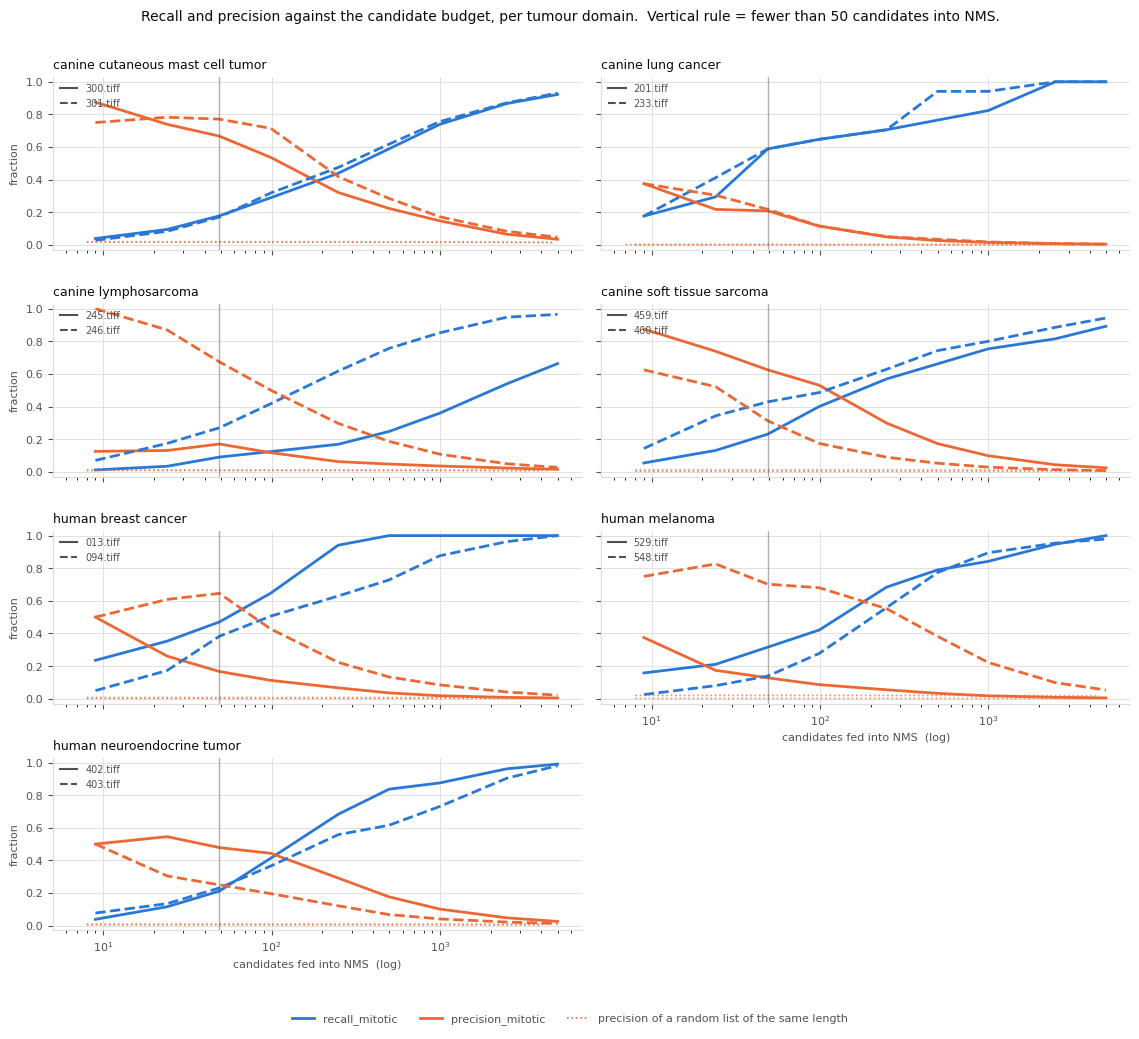

In [13]:
fin = curve[curve['budget_pre_nms'] > 0].copy()
domains = sorted(fin['tumor_type'].unique())
nrows = -(-len(domains) // 2)
fig, axes = plt.subplots(nrows, 2, figsize=(11.5, 2.5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, dom in zip(axes, domains):
    sub = fin[fin['tumor_type'] == dom]
    handles = []
    for style, fnm in zip(('-', '--'), sorted(sub['file_name'].unique())):
        s = sub[sub['file_name'] == fnm].sort_values('n_pre')
        ax.plot(s['n_pre'], s['R'], style, color=COL_RECALL, lw=2)
        ax.plot(s['n_pre'], s['P'], style, color=COL_PRECISION, lw=2)
        # the panel legend carries LINE STYLE only, in neutral ink: colour means the metric,
        # style means the ROI, and mixing the two into one key is how a legend starts lying.
        handles.append(Line2D([], [], color=INK_MUTED, ls=style, lw=1.5, label=fnm))
        nl = (bud[(bud['file_name'] == fnm) & (bud['budget_pre_nms'] > 0)]
              .groupby('n_detections')['null_precision'].median().sort_index())
        ax.plot(nl.index, nl.values, ':', color=COL_PRECISION, lw=1.2, alpha=0.7)
    ax.axvline(HEADLINE_BUDGET - 1, color=INK_MUTED, lw=1, alpha=0.45)
    ax.set_xscale('log')
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(dom, fontsize=9, color=INK, loc='left')
    ax.grid(True, which='major', color=GRID, lw=0.6)
    ax.set_axisbelow(True)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    for sp in ('left', 'bottom'):
        ax.spines[sp].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.legend(handles=handles, fontsize=7, frameon=False, loc='upper left',
              labelcolor=INK_MUTED, handlelength=1.8, borderpad=0.2)
for ax in axes[len(domains):]:
    ax.set_visible(False)
for ax in axes[:len(domains)][-2:]:
    ax.set_xlabel('candidates fed into NMS  (log)', fontsize=8, color=INK_MUTED)
    ax.tick_params(labelbottom=True)
for ax in axes[::2]:
    ax.set_ylabel('fraction', fontsize=8, color=INK_MUTED)

fig.legend(handles=[Line2D([], [], color=COL_RECALL, lw=2, label='recall_mitotic'),
                    Line2D([], [], color=COL_PRECISION, lw=2, label='precision_mitotic'),
                    Line2D([], [], color=COL_PRECISION, lw=1.2, ls=':',
                           label='precision of a random list of the same length')],
           loc='lower center', ncol=3, frameon=False, fontsize=8, labelcolor=INK_MUTED,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f'Recall and precision against the candidate budget, per tumour domain.  '
             f'Vertical rule = fewer than {HEADLINE_BUDGET} candidates into NMS.',
             fontsize=10, color=INK, y=1.005)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## The `recall` column, and why the old one was not a result

The complaint that started this notebook was that the recall in the earlier notebooks "isn't even
actual mathematical recall". I checked the arithmetic before renaming anything, and it is worth
being exact about what I found, because the fix is not the one the phrasing suggests.

**The arithmetic was right.** `compare.evaluate_arms` computes
`full_list_recall = tp_cum[-1] / n_mit`, where `tp_cum` counts detections bucketed
`human_correct_label`. `evaluate.greedy_match` maintains `gt_to_det` and claims each annotation at
most once, so that count is exactly the number of distinct mitotic annotations matched, and the
denominator is exactly that ROI's mitotic annotation count with the seed removed. TP / (TP + FN).
The same holds for `recall_at_budget`, for `deep_recall` in high_z and the ledger, and for
`recall_at_k` in `tm_recall_workload_curve.ipynb`. There is no wrong denominator anywhere in the
family, and Gate 2 above confirms it by making the harness recompute this notebook's own recall and
matching it to the bit.

**What was wrong is that it was reported alone, on a list long enough to make it inevitable.**
Three specific things, all measured above rather than argued:

1. **It is a candidate pool's recall, not a prediction set's.** At `z = 1.0` the list is 12,231 to
   38,876 points and `coverage_frac` is 0.9+ -- `evaluate.py`'s own docstring says that at that
   saturation the metric answers *"is this annotation within 7.5 um of some detection?"* by geometry
   rather than by evidence. At the budget this notebook uses, coverage is three orders of magnitude
   lower, and the recall reported there is evidence in a way the old number could not be.
2. **Recall without precision is not a detection metric.** It is maximised by emitting everything,
   which is close to what a 39,000-candidate list does. `full_list_recall == 1.0` appears on every
   row of every CSV in this family and the corresponding precision -- computable from the same
   frames, in one line -- appears in none of them. It is 0.05% to 1.5%.
3. **A budget in the column name that the list never delivered.** `recall_at_budget` is emitted at
   all of `cp.BUDGETS` regardless of list length, so a 40-detection arm carries a column headed
   `recall@5000`. `budget_delivered` records the truth in a neighbouring column, but a reader
   quoting the header is quoting a budget that did not happen.

So the column here is `recall_mitotic`, it is defined in one table in the metric-definitions cell,
and it never appears without `precision_mitotic`, `n_detections` and `coverage_frac` beside it.

In [14]:
print('The same code, the same ROIs, the same clicks, two operating points:\n')
cmp_ = pd.DataFrame({
    'z = 1.0 (what the old CSVs report)': [
        f"{z1['n_detections'].min()}-{z1['n_detections'].max()}",
        f"{z1['recall_mitotic'].min():.4f}-{z1['recall_mitotic'].max():.4f}",
        f"{z1['precision_mitotic'].min():.5f}-{z1['precision_mitotic'].max():.5f}",
        f"{z1['coverage_frac'].min():.3f}-{z1['coverage_frac'].max():.3f}",
        f"{(z1['precision_mitotic'] / z1['null_precision']).median():.2f}x",
        f"{z1['z_last_kept'].min():.2f}-{z1['z_last_kept'].max():.2f}"],
    f'fewer than {HEADLINE_BUDGET} into NMS': [
        f"{h['n_detections'].min()}-{h['n_detections'].max()}",
        f"{h['recall_mitotic'].min():.4f}-{h['recall_mitotic'].max():.4f}",
        f"{h['precision_mitotic'].min():.5f}-{h['precision_mitotic'].max():.5f}",
        f"{h['coverage_frac'].min():.5f}-{h['coverage_frac'].max():.5f}",
        f"{(h['precision_mitotic'] / h['null_precision']).median():.0f}x",
        f"{h['z_last_kept'].min():.2f}-{h['z_last_kept'].max():.2f}"],
}, index=['n_detections', 'recall_mitotic', 'precision_mitotic', 'coverage_frac',
          'precision / length-matched null', 'z at the cut'])
print(cmp_.to_string())
print(f"\nFull recall at z=1.0 in {int((z1['recall_mitotic'] == 1.0).sum())}/{len(z1)} cells, at a "
      f"median coverage of {z1['coverage_frac'].median():.3f}.")
print(f"Median full-list precision there: {z1['precision_mitotic'].median():.5f} "
      f"({z1['precision_mitotic'].median() * 100:.3f}%). That is the number the old recall column "
      f"was never printed next to.")
print(f"\nTotal notebook time {time.time() - NB_T0:.0f}s")

The same code, the same ROIs, the same clicks, two operating points:

                                z = 1.0 (what the old CSVs report) fewer than 50 into NMS
n_detections                                           10604-17659                  44-48
recall_mitotic                                       0.9551-1.0000          0.0000-0.6316
precision_mitotic                                  0.00113-0.01659        0.00000-0.89583
coverage_frac                                          0.661-0.955        0.00381-0.00434
precision / length-matched null                              1.40x                    67x
z at the cut                                             1.00-1.00             4.44-21.90

Full recall at z=1.0 in 57/70 cells, at a median coverage of 0.878.
Median full-list precision there: 0.00528 (0.528%). That is the number the old recall column was never printed next to.

Total notebook time 422s


## Closing summary

**The question, answered.** Pushing the cutoff until fewer than 50 candidates reach NMS puts it at
**z = 4.4 to 21.9** (median 7.8 over the 70 cells), against high_z's grid ceiling of 3.0. The
delivered list is **44-48 detections** and its **precision, per ROI over 5 clicks, is 0.128 to 0.771
(median ROI 0.395)**. Recall there is **0.090 to 0.588 by ROI** (median cell 0.277).

**Precision at a short list is a real measurement; precision at `z = 1.0` is not.** Scored against a
random list *of the same length* -- the only fair null, since one-to-one matching caps precision at
`n_gt / K` -- the `z = 1.0` pool of 10,604-17,659 candidates comes in at **1.24x-1.67x random
(median 1.40x)**. The same detector, the same click, at fewer than 50 candidates: **22x-146x by ROI,
median 67x per cell**. Twelve thousand candidates buy almost nothing over guessing; the detector's
entire measurable precision advantage lives at the head of the list, which is the only place the
earlier notebooks never looked.

**That is the answer to "the recall isn't real recall".** The arithmetic in the old column was
correct -- Gate 2 makes `compare.evaluate_arms` recompute this notebook's recall and it agrees in
70/70 cells to the bit. What was missing is the companion. `full_list_recall == 1.0` was reported at
`coverage_frac` **0.661-0.955**, where `evaluate.py`'s own docstring says the metric is answering
"is this annotation within 7.5 um of some detection?" by geometry; at the budget here coverage is
**0.0038-0.0043**, three orders of magnitude lower, and the same code's recall is evidence. The fix
is not a rename -- it is that `recall_mitotic` never appears without `precision_mitotic`,
`n_detections` and `coverage_frac` beside it.

**A correction to high_z that follows from this.** Its closing summary reports full-list precision
going "from 0.10-1.14% to 0.84-2.99% (1.4x-24.8x)" at `z_max`. Those are precisions computed against
**no null at all**, and the length-matched null measured here shows why that matters: at the `z = 1.0`
list length the null is already 0.08-1.17%, i.e. the same order as the number being quoted as the
before-state. The multiplier is real but it is a ratio of two numbers both close to chance, and it is
not evidence of a precision advantage until it is divided by a null of the same length. No number in
high_z is wrong; the reading of that one is.

**Precision is mostly prevalence, and the lift runs the other way.** Across the 14 ROIs,
Spearman(mitotic count, precision at <50) = **+0.84** -- `301.tiff` (217 annotations) reaches 0.771
while `529.tiff` (19) reaches 0.128. Against the length-matched null the ordering **inverts**:
Spearman(mitotic count, lift) = **-0.85**, with the sparse lung-cancer ROIs at 144x-146x and the
dense mast-cell ones at 41x-42x. Any cross-domain reading of a raw precision column is reading
density. This is the single easiest number here to quote wrongly.

**The worst cell is the finding D4 exists to surface.** `245.tiff` seed 1 returns **0 of 89 mitoses
in its top 49** -- precision 0.000, recall 0.000 -- while the same ROI at seed 4 returns 12. One
click's template is worth nothing at this budget on that ROI. `245.tiff` is also the ROI whose
median recall at <50 is lowest (0.090). A short list is not uniformly safe, and the failure is a
click failure, not a domain failure.

**Is 50 special? No.** Median-ROI F1 runs 0.206 (<25), 0.287 (<50), **0.316 (<100)**, so the F1
optimum sits nearer 100 than 50 -- but F1 weights a missed mitosis and a wasted click equally and
this product plainly does not, so that peak is a description of the curve and not a recommendation.
D4 already puts `K` outside the statistics. The curve itself, per ROI, is in
`results/tm_precision_under50_curve.csv` and the figure above; it is smooth and has no knee, which
is itself the useful answer.

## Two things this run changed relative to high_z, and what each cost

**1. The NMS radius is back at the 7.5 um default -- inert at the head, a ceiling cost at the tail.**
high_z and `recall_workload_ledger.py` ran 5.0 um, an override of `invariants.check_nms_radius`
inherited by copy from `tm_threshold_axis_sweep_v2.ipynb`; F5 concluded on 2026-09-08 that v2's gain
came from the padding, not the radius, and recommended reverting. F5 measured that at `K = 250` on a
full pool, so it is re-measured here at this budget rather than assumed to transfer, on the **same 49
peaks** suppressed both ways:

* true positives identical in **70/70** cells, recall delta exactly **0.0000** in every cell;
* list length differs in 16/70, always shorter at 7.5 um, worth **+0.000 to +0.028** precision;
* duplicate detections on an already-claimed mitosis: **4** at 7.5 um against **13** at 5.0 um.

So at the head of the list the radius is inert, and the reason to prefer the default is that it
restores Invariant 4 rather than that it wins.

**2. At the tail it is not inert, and Gate 1 caught the cost.** At 7.5 um the `z = 1.0` pool no longer reaches
full recall in **13 of 70 cells** (ceiling 0.955-0.995) where the ledger's 5.0 um run reached it in
70/70 -- concentrated on the dense ROIs (`300.tiff` at all five seeds, plus `245`, `246`, `301`,
`459`, `548`). The mechanism is fixed by elimination -- NMS is the only difference between the two
runs, and it drops a point only when a **higher-scoring kept point lies within the radius** -- so in
each of those 13 cells the detection that matched the mitosis was suppressed by a better-scoring
neighbour 20-33 px away. What that neighbour *is* is not separated here: it may be an unannotated
false positive, a pathologist-rejected look-alike, or (on `245.tiff` specifically) the second member
of the one mitotic pair F5's spacing table found close enough for the default radius to merge, at
26.57 px. Distinguishing them needs the lost annotations logged, which this run does not do. This is
the same effect F5 measured from the other direction ("24 gained, 0 lost at both doses" when
shrinking) and judged partly geometric, since coverage rises with it. Recorded here because it is a **ceiling** -- no
budget below `z = 1.0` can recover those mitoses -- and this notebook's recall column is bounded by
it. That is why `ceiling` sits beside `R@<50` in the headline table: on the 57 clean cells `R@<50` is
a statement about ranking, and on the other 13 it is not.

The two halves are one finding at two operating points, not a contradiction: suppression acts only
on candidates that are close together, and the top 49 peaks of a response map are not, while the
12,000-candidate pool is full of near neighbours.

## What this does not establish

* **The cutoffs are per-ROI, not deployable as a `z`.** The rule that produced them -- "take peaks
  until you have 50" -- is itself deployable and needs no labels, which is a genuine advantage over
  high_z's oracle `z_max`. The *`z` values* it lands on are not: they span 4.4 to 21.9, so no fixed
  `z` reproduces this operating point across ROIs. That is the same lesson high_z learned about
  `z_max`, arrived at from the other side.
* **One template configuration**, one channel, one method. The response map's peak structure is a
  property of the template, so nothing here transfers to a tightened or multi-scale template.
* **Seeds are drawn with replacement across indices** (high_z's rule, kept so the ledger gate works),
  so `n_clicks` in the headline table is the distinct-annotation count and is sometimes below 5.
* **`chromatin_od` was not run**, deliberately: re-ranking a fixed candidate set changes neither its
  full-list precision nor its recall, and those are the only two quantities reported here.
* **The null is uniform over the ROI, not over tissue** (D2 removed the mask), so every lift is
  mildly optimistic.